In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load Marc's final TTRPG dataset
ttrpg_df = pd.read_csv("../marc/ttrpg_database_final.csv")

# Check the dataset
print(ttrpg_df.shape)
print(ttrpg_df.columns.tolist())

ttrpg_df.head()

(986, 4)
['Name', 'Description', 'Average Score', 'Number of Reviews']


,Name,Description,Average Score,Number of Reviews
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41


In [3]:
# Make column names easier to use
ttrpg_df = ttrpg_df.rename(columns={
    "Name": "title",
    "Description": "description",
    "Average Score": "average_score",
    "Number of Reviews": "number_of_reviews"
})

# Check updated columns
print(ttrpg_df.columns.tolist())

ttrpg_df.head()

['title', 'description', 'average_score', 'number_of_reviews']


,title,description,average_score,number_of_reviews
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41


In [4]:
# Keep only rows with a usable title and description
ttrpg_df = ttrpg_df.dropna(subset=["title", "description"]).copy()

# Make sure descriptions are strings
ttrpg_df["description"] = ttrpg_df["description"].astype(str)

# Remove empty descriptions
ttrpg_df = ttrpg_df[ttrpg_df["description"].str.strip() != ""].copy()

# Remove duplicate titles if any
ttrpg_df = ttrpg_df.drop_duplicates(subset=["title"]).reset_index(drop=True)

print(ttrpg_df.shape)
ttrpg_df.head()

(972, 4)


,title,description,average_score,number_of_reviews
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41


experiment with diff preprocessing

In [6]:
# Preprocessing 1: Basic cleaning only
def preprocess_basic(text):
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Preprocessing 2: Keep only longer words
def preprocess_no_short_words(text):
    text = preprocess_basic(text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    return " ".join(words)


# Preprocessing 3: Remove common game-related words that may be too repetitive
def preprocess_remove_game_words(text):
    text = preprocess_no_short_words(text)
    
    custom_stopwords = {
        "game", "games", "role", "playing", "player", "players",
        "character", "characters", "rule", "rules", "system"
    }
    
    words = text.split()
    words = [word for word in words if word not in custom_stopwords]
    return " ".join(words)

In [7]:
#  Create Preprocessed Text Columns

ttrpg_df["text_basic"] = ttrpg_df["description"].apply(preprocess_basic)
ttrpg_df["text_no_short"] = ttrpg_df["description"].apply(preprocess_no_short_words)
ttrpg_df["text_custom_stopwords"] = ttrpg_df["description"].apply(preprocess_remove_game_words)

ttrpg_df[["title", "text_basi"
"c", "text_no_short", "text_custom_stopwords"]].head()

,title,text_basic,text_no_short,text_custom_stopwords
0,The Strange,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...
1,InSpectres,fighting the forces of darkness so you don t h...,fighting the forces darkness you don have insp...,fighting the forces darkness you don have insp...
2,Dungeons & Dragons Expert Set,the first version of the d d expert set it con...,the first version the expert set contains page...,the first version the expert set contains page...
3,The Character Compendium,an unofficial supplement for warhammer fantasy...,unofficial supplement for warhammer fantasy ro...,unofficial supplement for warhammer fantasy ro...
4,The Elves of Alfheim,this is the first gazetteer to outline a non h...,this the first gazetteer outline non human cul...,this the first gazetteer outline non human cul...


In [8]:
# Function to Run TF-IDF + SVD

def run_svd_experiment(text_data, experiment_name, max_features=5000, min_df=5, ngram_range=(1, 1), variance_threshold=0.90):
    """
    Runs TF-IDF and SVD on a text column.
    
    Returns:
    - experiment name
    - TF-IDF shape
    - number of singular values needed to reach variance threshold
    - total explained variance using all tested components
    - vectorizer
    - SVD model
    - transformed semantic vectors
    """
    
    # Convert text into TF-IDF vectors
    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range
    )
    
    X_tfidf = vectorizer.fit_transform(text_data)
    
    # SVD cannot use more components than number of features or rows
    max_components = min(X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1, 500)
    
    svd = TruncatedSVD(
        n_components=max_components,
        random_state=42
    )
    
    X_svd = svd.fit_transform(X_tfidf)
    
    # Compute cumulative explained variance
    cumulative_variance = svd.explained_variance_ratio_.cumsum()
    
    # Find number of singular values needed to reach threshold
    retained_svs = np.argmax(cumulative_variance >= variance_threshold) + 1
    
    # If threshold is not reached, use max_components
    if cumulative_variance[-1] < variance_threshold:
        retained_svs = max_components
    
    result = {
        "experiment": experiment_name,
        "max_features": max_features,
        "min_df": min_df,
        "ngram_range": str(ngram_range),
        "tfidf_rows": X_tfidf.shape[0],
        "tfidf_features": X_tfidf.shape[1],
        "retained_svs_for_90_percent": retained_svs,
        "explained_variance_at_retained_svs": cumulative_variance[retained_svs - 1],
        "max_explained_variance_tested": cumulative_variance[-1]
    }
    
    return result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance

In [9]:
# Run Different SVD Experiments

experiments = []

saved_outputs = {}

experiment_settings = [
    {
        "experiment_name": "Basic preprocessing + unigram TF-IDF",
        "text_column": "text_basic",
        "max_features": 5000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "No short words + unigram TF-IDF",
        "text_column": "text_no_short",
        "max_features": 5000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Custom stopwords + unigram TF-IDF",
        "text_column": "text_custom_stopwords",
        "max_features": 5000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic preprocessing + unigram/bigram TF-IDF",
        "text_column": "text_basic",
        "max_features": 5000,
        "min_df": 5,
        "ngram_range": (1, 2)
    },
    {
        "experiment_name": "Custom stopwords + unigram/bigram TF-IDF",
        "text_column": "text_custom_stopwords",
        "max_features": 5000,
        "min_df": 5,
        "ngram_range": (1, 2)
    }
]

for setting in experiment_settings:
    result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance = run_svd_experiment(
        text_data=ttrpg_df[setting["text_column"]],
        experiment_name=setting["experiment_name"],
        max_features=setting["max_features"],
        min_df=setting["min_df"],
        ngram_range=setting["ngram_range"]
    )
    
    experiments.append(result)
    
    saved_outputs[setting["experiment_name"]] = {
        "vectorizer": vectorizer,
        "svd": svd,
        "X_tfidf": X_tfidf,
        "X_svd": X_svd,
        "cumulative_variance": cumulative_variance
    }

results_df = pd.DataFrame(experiments)
results_df

,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,retained_svs_for_90_percent,explained_variance_at_retained_svs,max_explained_variance_tested
0,Basic preprocessing + unigram TF-IDF,5000,5,"(1, 1)",972,2994,500,0.836388,0.836388
1,No short words + unigram TF-IDF,5000,5,"(1, 1)",972,2968,500,0.836718,0.836718
2,Custom stopwords + unigram TF-IDF,5000,5,"(1, 1)",972,2958,500,0.835494,0.835494
3,Basic preprocessing + unigram/bigram TF-IDF,5000,5,"(1, 2)",972,3847,500,0.822329,0.822329
4,Custom stopwords + unigram/bigram TF-IDF,5000,5,"(1, 2)",972,3618,500,0.824934,0.824934


In [10]:
# Sort Results Table

results_df.sort_values(
    by=["retained_svs_for_90_percent", "explained_variance_at_retained_svs"],
    ascending=[True, False]
)

,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,retained_svs_for_90_percent,explained_variance_at_retained_svs,max_explained_variance_tested
1,No short words + unigram TF-IDF,5000,5,"(1, 1)",972,2968,500,0.836718,0.836718
0,Basic preprocessing + unigram TF-IDF,5000,5,"(1, 1)",972,2994,500,0.836388,0.836388
2,Custom stopwords + unigram TF-IDF,5000,5,"(1, 1)",972,2958,500,0.835494,0.835494
4,Custom stopwords + unigram/bigram TF-IDF,5000,5,"(1, 2)",972,3618,500,0.824934,0.824934
3,Basic preprocessing + unigram/bigram TF-IDF,5000,5,"(1, 2)",972,3847,500,0.822329,0.822329


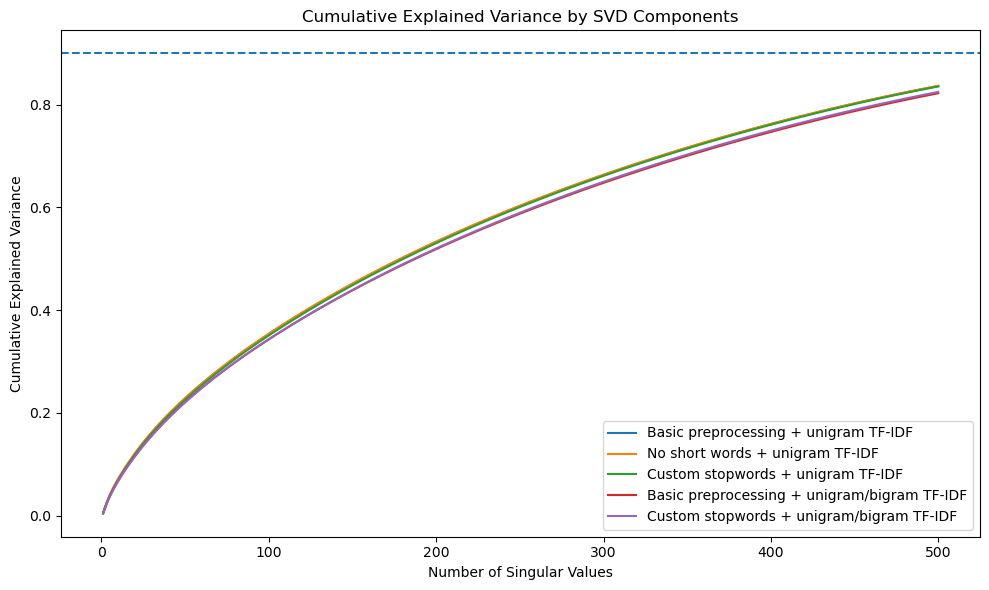

In [11]:
# Plot SVD Explained Variance for Each Experiment

plt.figure(figsize=(10, 6))

for experiment_name, output in saved_outputs.items():
    cumulative_variance = output["cumulative_variance"]
    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        label=experiment_name
    )

plt.axhline(0.90, linestyle="--")
plt.title("Cumulative Explained Variance by SVD Components")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Choose Best Experiment
# For now, we choose the one that reaches 90% variance with fewer singular values.

best_experiment_name = results_df.sort_values(
    by="retained_svs_for_90_percent",
    ascending=True
).iloc[0]["experiment"]

print("Best experiment:", best_experiment_name)

best_output = saved_outputs[best_experiment_name]

best_vectorizer = best_output["vectorizer"]
best_svd = best_output["svd"]
best_X_tfidf = best_output["X_tfidf"]
best_X_svd = best_output["X_svd"]

Best experiment: Basic preprocessing + unigram TF-IDF


In [13]:
# Simple IR System Using SVD Vectors

def search_games(query, text_preprocessor, vectorizer, svd, game_vectors, df, top_n=10):
    """
    Search for games similar to a user query.
    """
    
    # Preprocess the query
    clean_query = text_preprocessor(query)
    
    # Convert query to TF-IDF
    query_tfidf = vectorizer.transform([clean_query])
    
    # Convert query to SVD semantic vector
    query_svd = svd.transform(query_tfidf)
    
    # Compare query vector to all game vectors
    similarities = cosine_similarity(query_svd, game_vectors).flatten()
    
    # Create results table
    results = df[["title", "description"]].copy()
    results["similarity"] = similarities
    
    if "average_score" in df.columns:
        results["average_score"] = df["average_score"]
    
    if "number_of_reviews" in df.columns:
        results["number_of_reviews"] = df["number_of_reviews"]
    
    return results.sort_values("similarity", ascending=False).head(top_n)

In [ ]:
# Test IR Queries
# Change the query depending on what you want to test.

search_games(
    query="fantasy adventure with magic and dragons",
    text_preprocessor=preprocess_basic,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=ttrpg_df,
    top_n=10
)

,title,description,similarity,average_score,number_of_reviews
228,Dungeons & Dragons Basic Rulebook (Second Edit...,From the back of the book: DUNGEONS & DRAGONS ...,0.499430,7.99107,28
925,Dungeons & Dragons Basic Set (Second Edition),"From the back of the box: ""Fire and smoke surr...",0.437821,8.09080,250
391,GURPS Thaumatology,From the back of the book: Feel the Power! Fan...,0.429111,8.11539,26
906,Player's Handbook (D&D 4e),From the back cover: THE WORLD NEEDS HEROES. I...,0.354759,6.71498,442
264,Draconomicon: The Book of Dragons,"History, culture, ecology and rules for runnin...",0.338010,7.16049,81
302,The New Easy-to-Master Dungeons & Dragons Game,The fourth version of the basic Dungeons and D...,0.332148,7.32432,37
331,RuneQuest Deluxe Edition,"From the back cover: ""A Classic Roleplaying Sy...",0.327696,7.47872,94
350,The Burning Wheel: Magic Burner,"Magic: multifaceted, ephemeral and dangerous. ...",0.325538,8.02612,67
946,Dungeons & Dragons Rules Cyclopedia,From the Back Cover: Whether you're a player o...,0.315010,8.30506,257
90,Legends of Anglerre,Publisher's blurb: Legends of Anglerre shoves ...,0.314873,7.41667,36


In [15]:
# try another

search_games(
    query="horror mystery investigation supernatural monsters",
    text_preprocessor=preprocess_basic,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=ttrpg_df,
    top_n=10
)

,title,description,similarity,average_score,number_of_reviews
1,InSpectres,Fighting the Forces of Darkness so you don't h...,0.443377,7.57355,138
463,Monster of the Week (Revised),From the publisher blurb: A monster lurks in t...,0.433664,7.92333,75
199,World of Darkness,Where the Shadows Grow Long We live our days c...,0.370718,7.25393,242
657,Trail of Cthulhu,"""That is not dead which can eternal lie. And w...",0.307629,8.00190,263
95,Unknown Armies,From the cover: A Roleplaying Game of Transcen...,0.287562,7.73404,47
880,Call of Cthulhu Starter Set,"Publisher blurb: A World of Mystery, Horror an...",0.278777,8.75062,80
283,Monsters and Other Childish Things: The Comple...,Publisher blurb: Monsters are real. You know b...,0.272949,7.72500,40
247,Vaesen,Nordic Horror Roleplaying From the introductio...,0.261104,8.01013,74
275,GURPS Cabal,A setting for GURPS Horror or GURPS Illuminati...,0.229335,8.21429,14
689,The Between (Preview Edition),(From DTRPG:) The Between is a tabletop rolepl...,0.225300,9.08333,12


In [16]:
# try another

search_games(
    query="science fiction space exploration cyberpunk future",
    text_preprocessor=preprocess_basic,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=ttrpg_df,
    top_n=10
)

,title,description,similarity,average_score,number_of_reviews
173,Genesys Core Rulebook,Description from the publisher: Face down a dr...,0.429461,8.09615,52
375,MegaTraveller,Science-Fiction Adventure in the Shattered Imp...,0.391455,6.94583,60
922,Traveller Boxed Set,From the Box: Welcome to the exciting universe...,0.388042,8.02099,181
678,Traveller,"From the back of the book: ""Traveller is back....",0.340550,7.51348,115
256,Space: 1889,Space: 1889 is based upon the scientific roman...,0.339573,7.11786,70
67,The Traveller Book,From Inside Dust Jacket of Hardcover Version: ...,0.338514,8.17574,68
858,GURPS Space (Third Edition),"From the back of the book: ""GURPS Space is the...",0.320069,7.60526,38
814,2300 AD,2300AD is a hard science-fiction role-playing ...,0.310370,7.28917,60
740,Cyberpunk 2020,From the back of the book... The Roleplaying G...,0.306931,7.52848,223
811,Traveller Core Rulebook,From publisher blurb: This is Free Trader Beow...,0.278225,7.94643,28


In [17]:
# save results table

results_df.to_csv("svd_experiment_results.csv", index=False)
results_df

,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,retained_svs_for_90_percent,explained_variance_at_retained_svs,max_explained_variance_tested
0,Basic preprocessing + unigram TF-IDF,5000,5,"(1, 1)",972,2994,500,0.836388,0.836388
1,No short words + unigram TF-IDF,5000,5,"(1, 1)",972,2968,500,0.836718,0.836718
2,Custom stopwords + unigram TF-IDF,5000,5,"(1, 1)",972,2958,500,0.835494,0.835494
3,Basic preprocessing + unigram/bigram TF-IDF,5000,5,"(1, 2)",972,3847,500,0.822329,0.822329
4,Custom stopwords + unigram/bigram TF-IDF,5000,5,"(1, 2)",972,3618,500,0.824934,0.824934
